In [50]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [51]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_v2_s,
    EfficientNet_V2_S_Weights,
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

from tqdm import tqdm

# ==========================================================
# Configuration
# ==========================================================

TRAIN_DIR = pathtrain

OUT_DIR = "models"
OUT_PATH = os.path.join(OUT_DIR, "best_gesture_model.pth")

ARCHITECTURE = "efficientnet_v2_s"

IMG_SIZE = 224
BATCH_SIZE = 32

FREEZE_EPOCHS = 5
FINETUNE_EPOCHS = 3

HEAD_LR = 3e-4
FINETUNE_LR = 1e-5

WEIGHT_DECAY = 1e-4

STEP_SIZE = 7
GAMMA = 0.5

EARLY_STOP_PATIENCE = 1

NUM_WORKERS = min(4, os.cpu_count() or 1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

LETTER_TO_COMMAND = {
    "A": "SHOULDER_FORWARD",
    "B": "STOP",
    "C": "SHOULDER_BACKWARD",
    "D": "FORWARD",
    "G": "LEFT",
    "H": "YAW_LEFT",
    "I": "ELBOW_DOWN",
    "K": "RIGHT",
    "L": "BACKWARD",
    "O": "GRIPPER_OPEN",
    "S": "GRIPPER_CLOSE",
    "U": "YAW_RIGHT",
    "Y": "ELBOW_UP",
}

os.makedirs(OUT_DIR, exist_ok=True)

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

In [52]:
# ==========================================================
# Custom Dataset
# ==========================================================

class RobotGestureDataset(Dataset):
    """
    Loads only the gestures used by the robot and remaps labels to 0-12.

    Original dataset:
        A B C D ... Y Z del nothing space

    Robot dataset:
        A B C D G H I K L O S U Y
    """

    def __init__(self, root_dir, transform=None):
        self.transform = transform

        base_dataset = datasets.ImageFolder(root_dir)

        self.classes = sorted(LETTER_TO_COMMAND.keys())

        # Map letter -> new label (0-12)
        self.class_to_idx = {
            letter: idx
            for idx, letter in enumerate(self.classes)
        }

        self.samples = []

        for image_path, old_label in base_dataset.samples:

            letter = base_dataset.classes[old_label]

            if letter not in self.class_to_idx:
                continue

            new_label = self.class_to_idx[letter]

            self.samples.append((image_path, new_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = datasets.folder.default_loader(image_path)

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [53]:
# ==========================================================
# Data Transforms
# ==========================================================

def build_transforms():

    train_transform = transforms.Compose([

        transforms.RandomRotation(15),

        transforms.RandomAffine(
            degrees=10,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05)
        ),

        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),

        transforms.ToTensor(),

        transforms.Normalize(MEAN, STD)
    ])

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD)
    ])

    return train_transform, val_transform


train_transform, val_transform = build_transforms()

In [54]:
# ==========================================================
# Robot Gesture Dataset
# ==========================================================

class RobotGestureDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform

        base_dataset = datasets.ImageFolder(root_dir)

        # Robot gestures only
        self.classes = sorted(LETTER_TO_COMMAND.keys())

        # New labels (0-12)
        self.class_to_idx = {
            letter: idx
            for idx, letter in enumerate(self.classes)
        }

        self.samples = []

        for image_path, old_label in base_dataset.samples:

            letter = base_dataset.classes[old_label]

            if letter not in self.class_to_idx:
                continue

            new_label = self.class_to_idx[letter]

            self.samples.append((image_path, new_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = datasets.folder.default_loader(image_path)

        if self.transform:
            image = self.transform(image)

        return image, label

In [55]:
# ==========================================================
# Build Dataset
# ==========================================================

full_dataset = RobotGestureDataset(
    TRAIN_DIR,
    transform=None
)

labels = [label for _, label in full_dataset.samples]

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_indices, val_indices = next(
    splitter.split(
        np.zeros(len(labels)),
        labels
    )
)

In [56]:
# ==========================================================
# Train / Validation Datasets
# ==========================================================

train_dataset = copy.deepcopy(full_dataset)
val_dataset = copy.deepcopy(full_dataset)

train_dataset.transform = train_transform
val_dataset.transform = val_transform

train_dataset.samples = [
    full_dataset.samples[i]
    for i in train_indices
]

val_dataset.samples = [
    full_dataset.samples[i]
    for i in val_indices
]

In [57]:
print(f"Training images   : {len(train_dataset)}")
print(f"Validation images : {len(val_dataset)}")

print("\nRobot classes:")
print(train_dataset.classes)

print("\nCommand mapping:")
for letter in train_dataset.classes:
    print(f"{letter:>2}  ->  {LETTER_TO_COMMAND[letter]}")

Training images   : 31200
Validation images : 7800

Robot classes:
['A', 'B', 'C', 'D', 'G', 'H', 'I', 'K', 'L', 'O', 'S', 'U', 'Y']

Command mapping:
 A  ->  SHOULDER_FORWARD
 B  ->  STOP
 C  ->  SHOULDER_BACKWARD
 D  ->  FORWARD
 G  ->  LEFT
 H  ->  YAW_LEFT
 I  ->  ELBOW_DOWN
 K  ->  RIGHT
 L  ->  BACKWARD
 O  ->  GRIPPER_OPEN
 S  ->  GRIPPER_CLOSE
 U  ->  YAW_RIGHT
 Y  ->  ELBOW_UP


In [58]:
# ==========================================================
# Data Loaders
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")

Train batches      : 975
Validation batches : 244


In [59]:
# ==========================================================
# Build Model
# ==========================================================

weights = EfficientNet_V2_S_Weights.DEFAULT

model = efficientnet_v2_s(weights=weights)

# Replace the classifier
in_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(
    in_features,
    len(train_dataset.classes)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

print(model)

print(f"\nNumber of classes: {len(train_dataset.classes)}")
print(f"Output neurons   : {model.classifier[-1].out_features}")

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [60]:
# ==========================================================
# Unfreeze Backbone
# ==========================================================

def unfreeze_backbone(model):

    for param in model.features.parameters():
        param.requires_grad = True

    return model

In [61]:
# ==========================================================
# Loss, Optimizer, Scheduler & AMP
# ==========================================================

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)

from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

scaler = torch.cuda.amp.GradScaler(
    enabled=torch.cuda.is_available()
)


# ==========================================================
# Train One Epoch
# ==========================================================

def train_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, leave=False)

    for images, labels in progress:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# ==========================================================
# Validation
# ==========================================================

@torch.no_grad()
def validate_epoch(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    predictions_all = []
    labels_all = []

    for images, labels in loader:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        predictions_all.extend(predictions.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return (
        epoch_loss,
        epoch_acc,
        labels_all,
        predictions_all,
    )

/tmp/ipykernel_869/4231231871.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


In [62]:
# ==========================================================
# Training Loop
# ==========================================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_weights = copy.deepcopy(model.state_dict())

best_val_acc = 0.0
patience = 0


def train_model(num_epochs):

    global best_val_acc
    global best_weights
    global patience

    for epoch in range(num_epochs):

        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 50)

        train_loss, train_acc = train_epoch(
            model,
            train_loader,
        )

        val_loss, val_acc, y_true, y_pred = validate_epoch(
            model,
            val_loader,
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Train Loss : {train_loss:.4f} | "
            f"Train Acc : {train_acc*100:.2f}%"
        )

        print(
            f"Val Loss   : {val_loss:.4f} | "
            f"Val Acc   : {val_acc*100:.2f}%"
        )

        if val_acc > best_val_acc:

            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

            patience = 0

            print("✅ Best model updated.")

        else:

            patience += 1

            print(
                f"No improvement "
                f"({patience}/{EARLY_STOP_PATIENCE})"
            )

            if patience >= EARLY_STOP_PATIENCE:

                print("\nEarly stopping triggered.")
                break

    return y_true, y_pred


# ==========================================================
# Stage 1
# ==========================================================

print("=" * 60)
print("Stage 1 : Training Classifier")
print("=" * 60)

y_true, y_pred = train_model(FREEZE_EPOCHS)


# ==========================================================
# Stage 2
# ==========================================================

print("\n")
print("=" * 60)
print("Stage 2 : Fine Tuning")
print("=" * 60)

model = unfreeze_backbone(model)

optimizer = AdamW(
    model.parameters(),
    lr=FINETUNE_LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(
    optimizer,
    step_size=STEP_SIZE,
    gamma=GAMMA,
)

patience = 0

y_true, y_pred = train_model(FINETUNE_EPOCHS)

model.load_state_dict(best_weights)

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")

Stage 1 : Training Classifier

Epoch 1/5
--------------------------------------------------


  0%|          | 0/975 [00:00<?, ?it/s]/tmp/ipykernel_869/4231231871.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Train Loss : 1.6733 | Train Acc : 58.24%
Val Loss   : 1.3751 | Val Acc   : 73.53%
✅ Best model updated.

Epoch 2/5
--------------------------------------------------


Train Loss : 1.0836 | Train Acc : 71.13%
Val Loss   : 1.0244 | Val Acc   : 78.27%
✅ Best model updated.

Epoch 3/5
--------------------------------------------------


Train Loss : 0.9106 | Train Acc : 73.72%
Val Loss   : 0.9038 | Val Acc   : 80.59%
✅ Best model updated.

Epoch 4/5
--------------------------------------------------


...

Train Loss : 0.7910 | Train Acc : 76.05%
Val Loss   : 0.7744 | Val Acc   : 81.24%
✅ Best model updated.


Stage 2 : Fine Tuning

Epoch 1/3
--------------------------------------------------


/tmp/ipykernel_869/2527321567.py:39: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


Train Loss : 0.1247 | Train Acc : 96.12%
Val Loss   : 0.0147 | Val Acc   : 99.72%
✅ Best model updated.

Epoch 2/3
--------------------------------------------------


Train Loss : 0.0141 | Train Acc : 99.67%
Val Loss   : 0.0035 | Val Acc   : 99.96%
✅ Best model updated.

Epoch 3/3
--------------------------------------------------


Train Loss : 0.0058 | Train Acc : 99.87%
Val Loss   : 0.0017 | Val Acc   : 99.97%
✅ Best model updated.

Training Complete!
Best Validation Accuracy: 99.97%



Classification Report

              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       600
           B     1.0000    1.0000    1.0000       600
           C     1.0000    1.0000    1.0000       600
           D     1.0000    0.9983    0.9992       600
           G     0.9983    1.0000    0.9992       600
           H     1.0000    1.0000    1.0000       600
           I     1.0000    1.0000    1.0000       600
           K     1.0000    0.9983    0.9992       600
           L     1.0000    1.0000    1.0000       600
           O     0.9983    1.0000    0.9992       600
           S     1.0000    1.0000    1.0000       600
           U     1.0000    1.0000    1.0000       600
           Y     1.0000    1.0000    1.0000       600

    accuracy                         0.9997      7800
   macro avg     0.9997    0.9997    0.9997      7800
weighted avg     0.9997    0.9997    0.9997      7800



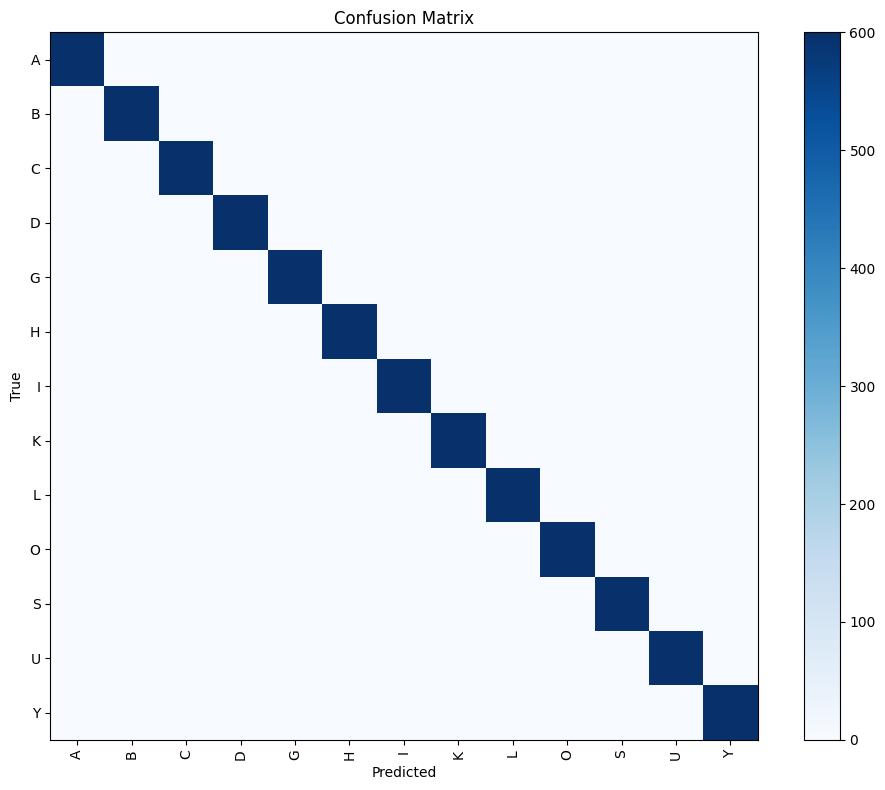

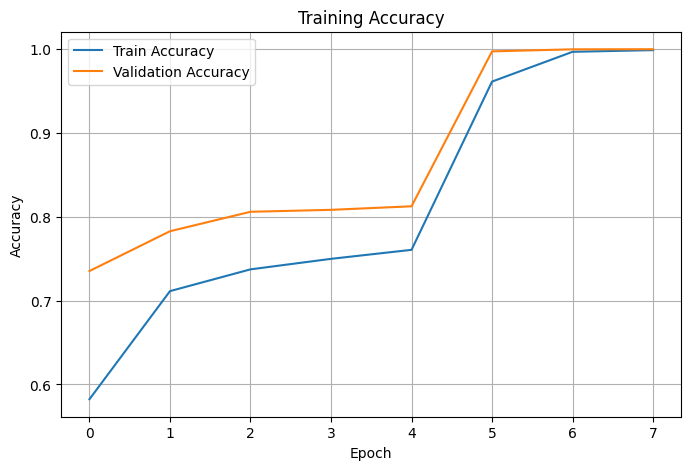

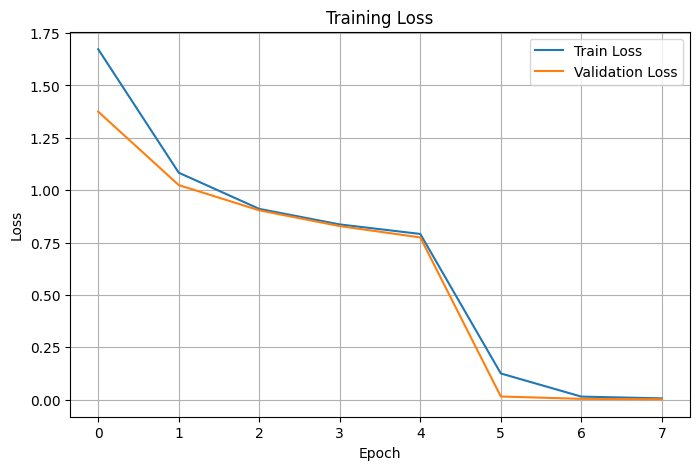


Model saved successfully!
models/best_gesture_model.pth


In [63]:
# ==========================================================
# Evaluation
# ==========================================================

import matplotlib.pyplot as plt

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

ticks = np.arange(len(train_dataset.classes))

plt.xticks(
    ticks,
    train_dataset.classes,
    rotation=90,
)

plt.yticks(
    ticks,
    train_dataset.classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()


# ==========================================================
# Accuracy & Loss Curves
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy",
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)

plt.show()


# ==========================================================
# Save Best Model
# ==========================================================

torch.save(
    {
        "architecture": ARCHITECTURE,
        "model_state_dict": model.state_dict(),
        "classes": train_dataset.classes,
        "letter_to_command": LETTER_TO_COMMAND,
        "image_size": IMG_SIZE,
        "mean": MEAN,
        "std": STD,
    },
    OUT_PATH,
)

print("\nModel saved successfully!")
print(OUT_PATH)